# Star Observatory

Task author: Asandei Stefan-Alexandru

## Overview
Ground-based astronomy faces a fundamental challenge: the Earth's atmosphere. While space telescopes enjoy a pristine view of the cosmos, terrestrial observatories must contend with turbulent air masses that distort incoming light. This turbulence causes stars to twinkle, a phenomenon known as scintillation, and blurs celestial images, spreading the light of a point source over a larger area. This degradation limits the precision with which astronomers can measure the brightness of stars.

In this task, you act as a data scientist for the Star Observatory. We are conducting a survey to measure the intrinsic brightness (flux) of thousands of stars. However, our measurements are heavily affected by varying atmospheric conditions. The amount of atmosphere the light passes through (airmass) and the severity of atmospheric turbulence (seeing) change constantly throughout the night.

Your goal is to build a machine learning model that recovers the **calibrated target flux** of a star. You are provided with the captured image of the star and the meteorological metadata recorded at the moment of observation. You must learn the relationship between the atmospheric parameters, the distorted image, and the underlying flux of the star.

### Physics Background
To solve this task, you must understand how astronomers measure light and how the atmosphere affects those measurements.

**Flux and Magnitude**: In astronomy, the brightness of a star is described by its Flux ($ F $), which represents the energy received per unit area per unit time. Historically, brightness is often denoted by Magnitude ($ m $), which is a logarithmic scale. The relationship between Flux and Magnitude is defined as:

$$ m = -2.5 \log_{10}(F) + C $$

Where $ C $ is a zero-point constant. Conversely, if we know the magnitude, the flux is proportional to $ 10^{-0.4m} $.

**Atmospheric Parameters**: The state of the atmosphere is defined by two primary values in our dataset:
*   **Airmass ($ X $):** A measure of the amount of air the light passes through. If a star is directly overhead (zenith), $ X=1 $. As the star moves toward the horizon, $ X $ increases. More airmass generally means more light is absorbed or scattered (extinction).
*   **Fried Parameter ($ r_0 $):** This measures the quality of "seeing", or atmospheric turbulence. It represents the diameter of the telescope aperture over which the atmosphere is coherent. **Higher $ r_0 $ indicates calmer air and better images;** lower $ r_0 $ results in more blurring.

**Image Formation**: Ideally, a star is a point source. However, due to diffraction and atmospheric turbulence, the light is spread out into a blob called the Point Spread Function (PSF). The observed image $ I(x,y) $ can be modeled as the convolution of the true star flux $ S $ with the atmospheric PSF, plus background noise $ N $:

$$ I(x,y) = (S * \text{PSF}_{r_0, X})(x,y) + N $$

The shape and width of the PSF are highly dependent on $ r_0 $ and $ X $. Additionally, the sensor introduces Poisson (photon) noise and electronic readout noise.

In [140]:
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
import numpy as np

import torch
import torchvision.transforms.v2 as T
from torch.utils.data import Dataset, DataLoader

In [141]:
root_path = "." # dataset path
device = "cuda" if torch.cuda.is_available() else "cpu"

torch.manual_seed(42)
np.random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

batch_size = 16

# Data

The dataset comprises 1,000 training images and 300 test images, each $ 128 \times 128 $ pixels. Every image contains precisely one star. The training data includes the true target flux values, while the test set requires prediction. The provided files are:
*   `train_images/00000.png` through `00999.png`: Training images
*   `train.csv`: Metadata including `image_id`, `fried_parameter`, `airmass` and `target_flux`
*   `test_images/00000.png` through `00299.png`: Test images
*   `test.csv`: Test metadata with `image_id` only

In [142]:
class AstralDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_path = f"{root_path}/train_images/{row['image_id']}"
        image = Image.open(img_path).convert("L")
        if self.transform:
            image = self.transform(image)

        if "m" in row:
            target = row["m"]
            return image, torch.tensor(target, dtype=torch.float32)

        return image

    def __len__(self):
        return len(self.df)

In [143]:
from sklearn.model_selection import train_test_split
train_df = pd.read_csv(f"{root_path}/train.csv")
train_df['m'] = -2.5 * np.log10(train_df['target_flux'])
train_df = train_df[train_df['m'] < -6]
train_df, val_df = train_test_split(train_df, test_size=0.1)

In [144]:
transform = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True)
])

val_transform = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True)
])

train_ds = AstralDataset(train_df, transform)
val_ds = AstralDataset(val_df, val_transform)

train_loader = DataLoader(train_ds, batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size, shuffle=False)

In [145]:
batch = next(iter(train_loader))
[b.shape for b in batch]

[torch.Size([16, 1, 128, 128]), torch.Size([16])]

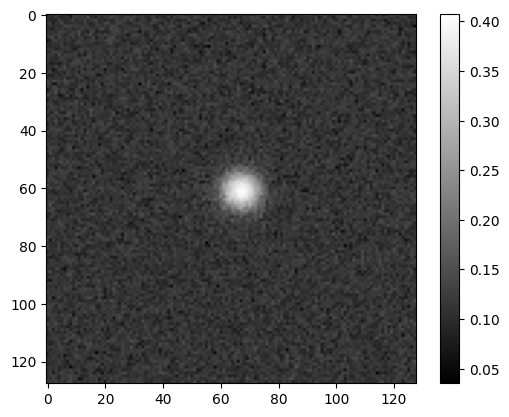

In [146]:
sample_idx = 0
sample_img = batch[0][sample_idx].permute(1, 2, 0)
plt.imshow(sample_img, cmap='gray')
plt.colorbar()

# Subtask 1: Star Center Prediction (20 Points)
Each image contains one star, and you have to compute each center's coordinates within the image. The answer has to be in the format of a tuple with 2 elements.

In [147]:
def get_center(img):
    img = np.array(img).squeeze(2)
    max = np.argmax(img)
    row = max // 128
    col = max % 128
    r = 15
    region = img[row-r:row+r, col-r:col+r]
    x, y = np.indices(region.shape)
    xc = int((x*region).sum() / region.sum())
    yc = int((y*region).sum() / region.sum())
    return (xc, yc)

# Subtask 2: Flux Prediction (80 Points)
Predict the `target_flux` (continuous value) of each star given its image and atmospheric parameters. The test set only has images.

In [148]:
def get_img(entry):
    return Image.open('train_images/' + entry['image_id'])

<Axes: >

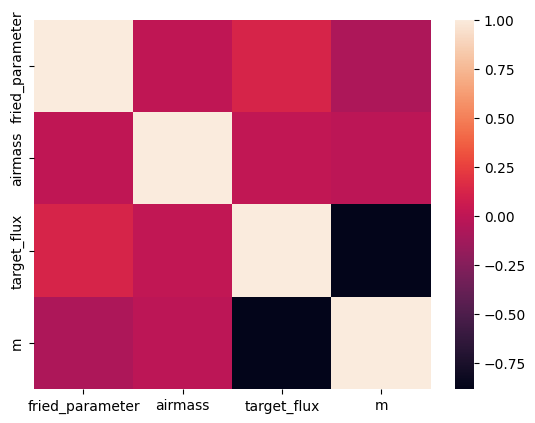

In [149]:
import seaborn as sns
heatmap_df = train_df.drop('image_id', axis=1)
sns.heatmap(heatmap_df.corr())

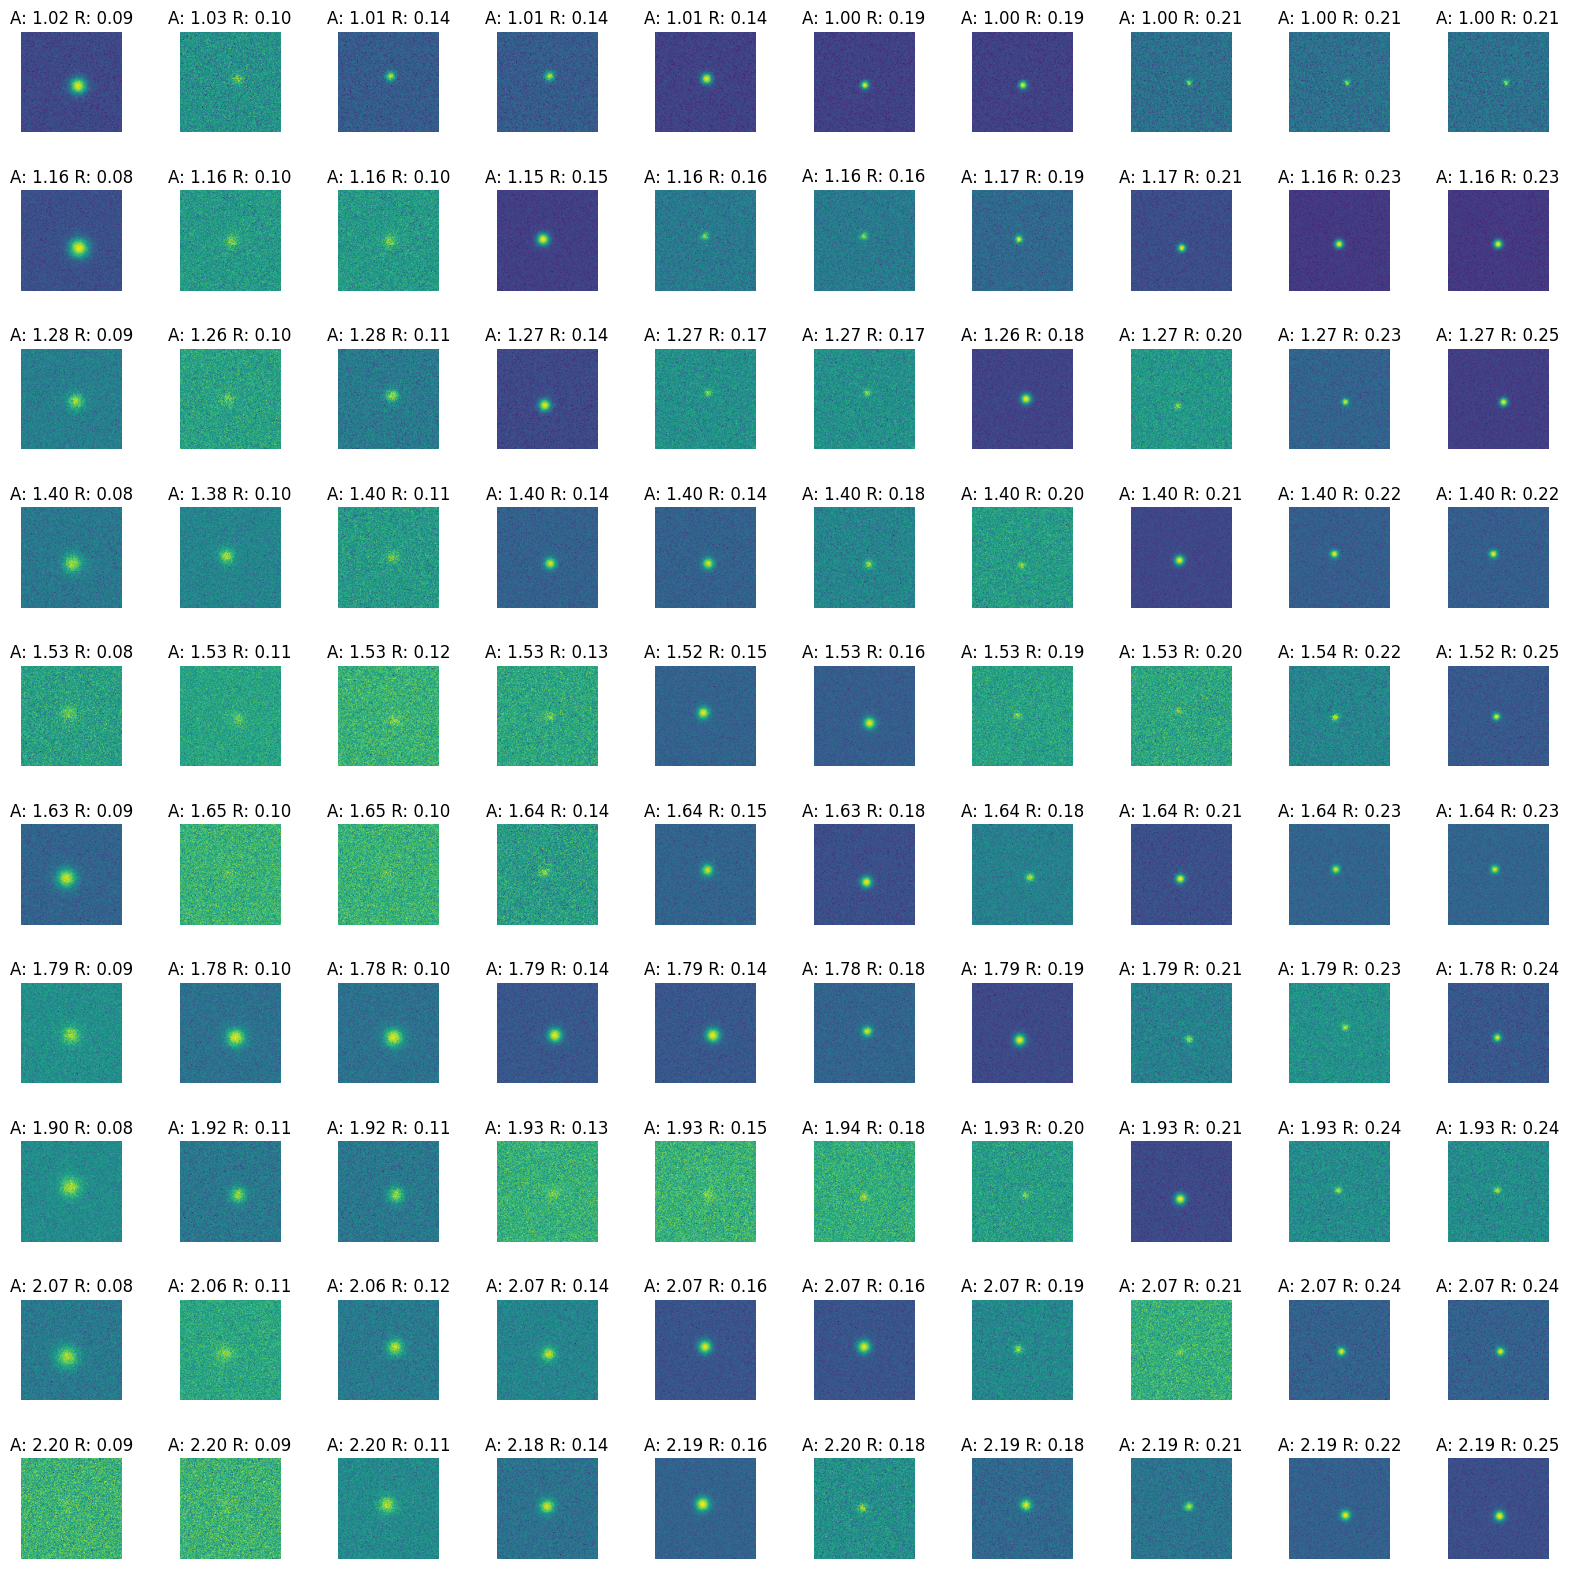

In [150]:
airmass_quantiles = train_df['airmass'].quantile(np.linspace(0, 1, 10))
r_quantiles = train_df['fried_parameter'].quantile(np.linspace(0, 1, 10))
fig, ax = plt.subplots(10, 10)
fig.set_size_inches(16, 16)
plt.tight_layout()
for i, airmass in enumerate(airmass_quantiles):
    for j, r in enumerate(r_quantiles):
        entry = train_df.iloc[((train_df["airmass"] - airmass).abs() + (train_df["fried_parameter"] - r).abs()).argmin()]
        ax[i, j].imshow(get_img(entry))
        entry_a = entry['airmass']
        entry_r = entry['fried_parameter']
        entry_m = entry['m']
        ax[i, j].set_title(f'A: {entry_a:.2f} R: {entry_r:.2f}')
        ax[i,j].axis('off')


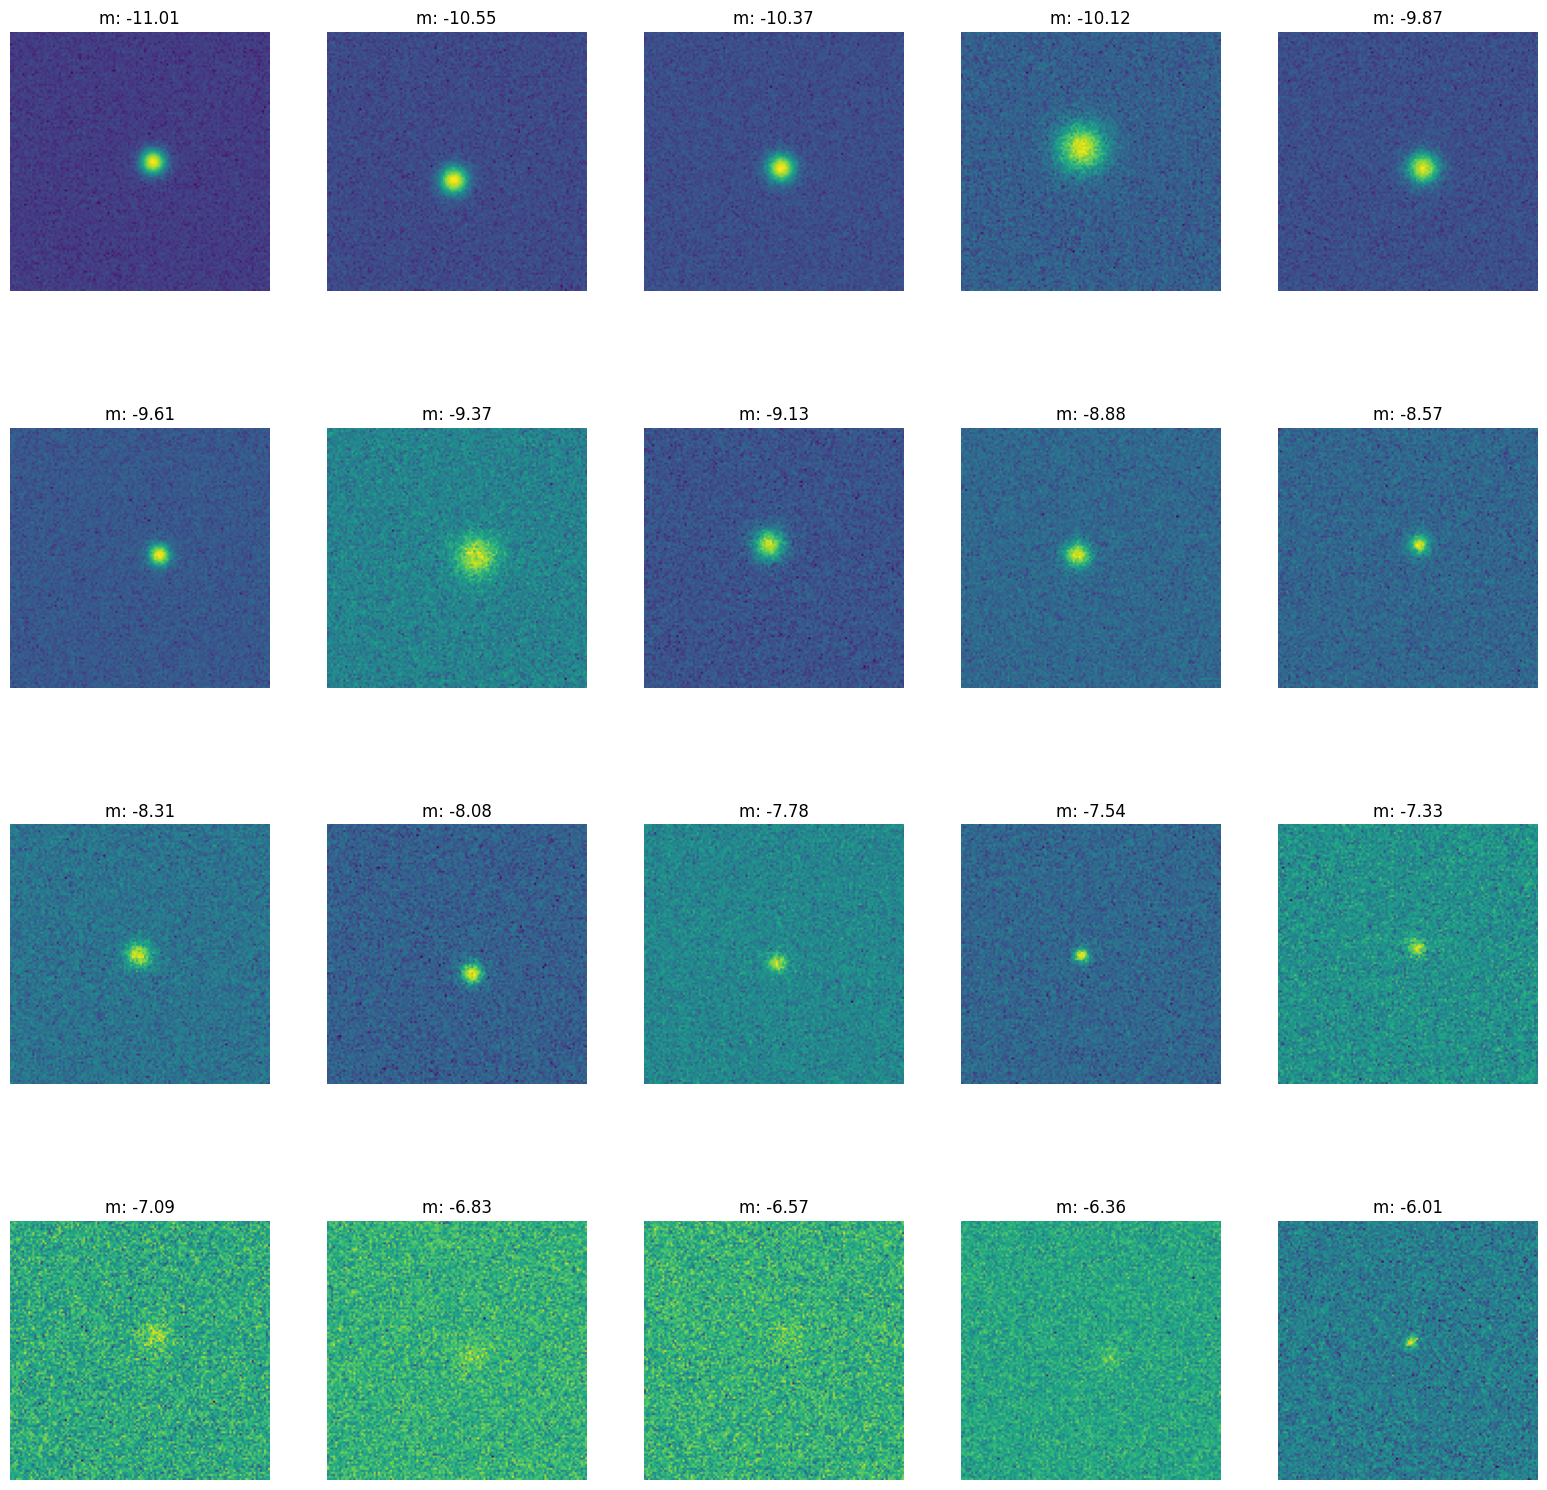

In [151]:
airmass_quantiles = train_df['m'].quantile(np.linspace(0, 1, 20))
fig, ax = plt.subplots(4, 5)
ax = ax.flatten()
fig.set_size_inches(16, 16)
plt.tight_layout()
for i, airmass in enumerate(airmass_quantiles):
        entry = train_df.iloc[((train_df["m"] - airmass).abs()).argmin()]
        ax[i].imshow(get_img(entry))
        entry_m = entry['m']
        ax[i].set_title(f'm: {entry_m:.2f}')
        ax[i].axis('off')


In [152]:
from torch import nn
model = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, padding=1, bias=False),
    nn.BatchNorm2d(32),
    nn.ReLU(True),

    nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False),
    nn.BatchNorm2d(32),
    nn.ReLU(True),

    nn.MaxPool2d(2),

    nn.Conv2d(32, 32, kernel_size=3, padding=1, groups=32, bias=False),
    nn.Conv2d(32, 64, kernel_size=1, bias=False),
    nn.BatchNorm2d(64),
    nn.ReLU(True),

    nn.MaxPool2d(2),

    nn.Conv2d(64, 64, kernel_size=3, padding=1, groups=32, bias=False),
    nn.Conv2d(64, 128, kernel_size=1, bias=False),
    nn.BatchNorm2d(128),
    nn.ReLU(True),

    nn.AdaptiveAvgPool2d((1,1)),
    nn.Flatten(),
    nn.Linear(128, 16),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(16, 1)
)

In [175]:
import torch.nn.functional as F
class FiLMBlock(nn.Module):
    def __init__(self, channels, meta_dim=2):
        super().__init__()
        self.gen = nn.Sequential(
            nn.Linear(meta_dim, 32), nn.ReLU(), nn.Linear(32, channels * 2)
        )

    def forward(self, x, meta):
        params = self.gen(meta).unsqueeze(-1).unsqueeze(-1)
        gamma, beta = torch.split(params, params.size(1) // 2, dim=1)
        return x * (1 + gamma) + beta


class AstroBlock(nn.Module):
    def __init__(self, in_c, out_c, stride=1, use_film=True):
        super().__init__()
        self.conv1 = nn.Conv2d(in_c, out_c, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_c)
        self.conv2 = nn.Conv2d(out_c, out_c, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_c)
        self.film = FiLMBlock(out_c) if use_film else nn.Identity()

        self.shortcut = nn.Sequential()
        if stride != 1 or in_c != out_c:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_c, out_c, 1, stride, bias=False), nn.BatchNorm2d(out_c)
            )

    def forward(self, x, meta=None):
        out = F.relu(self.bn1(self.conv1(x)))
        if meta is not None:
            out = self.film(out, meta)
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return F.relu(out)


class TeacherNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.stem = nn.Conv2d(1, 32, 3, 1, 1, bias=False)
        self.bn_stem = nn.BatchNorm2d(32)

        self.layer1 = AstroBlock(32, 64, stride=1)
        self.layer2 = AstroBlock(64, 128, stride=2)
        self.layer3 = AstroBlock(128, 256, stride=2)

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, 1))

    def forward(self, img):
        x = F.relu(self.bn_stem(self.stem(img)))
        f1 = self.layer1(x)
        f2 = self.layer2(f1)
        f3 = self.layer3(f2)

        pooled = self.pool(f3).view(f3.size(0), -1)
        out = self.fc(pooled).squeeze(-1)
        return out



In [ ]:
from torchvision.models import efficientnet_b0
# model = efficientnet_b0()
# model.features[0][0] = nn.Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
# model.classifier = nn.Sequential(
#     nn.Dropout(p=0.2, inplace=True),
#     nn.Linear(in_features=1280, out_features=1, bias=True)
#   )
model = TeacherNet()
model.to(device)
criterion = nn.MSELoss()
epochs = 50
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

best_acc=0.0
best_val_loss = float('inf')
for epoch in range(epochs):
    model.train()
    tr_loss=tr_total=0.0
    for x,y in train_loader:
        x,y=x.to(device),y.to(device)
        out=model(x)#.squeeze(1)
        loss=criterion(out,y)
        # diff = (torch.exp(-0.4 * out * torch.log(torch.tensor(10.0))) - torch.exp(-0.4 * y   * torch.log(torch.tensor(10.0))))
        # loss = diff.pow(2).mean()

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        tr_loss+=loss.item()*x.size(0)
        tr_total+=y.size(0)
    tr_loss/=tr_total

    model.eval()
    val_loss=val_correct=val_total=0.0
    real_loss = 0.0
    with torch.no_grad():
        for x,y in val_loader:
            x,y=x.to(device),y.to(device)
            out=model(x)#.squeeze(1)
            loss=criterion(out,y)
            real_loss += ((10**(-0.4*out) - 10**(-0.4*y))**2).sum()
            val_loss+=loss.item()*x.size(0)
            val_total+=y.size(0)

    val_loss/=val_total
    real_loss/=val_total

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pt")

    real_loss = torch.sqrt(real_loss)
    print(f"ep{epoch+1} tr_loss {tr_loss:.4f} val_loss {val_loss:.4f} REAL LOSS: {real_loss}")


ep1 tr_loss 26.5169 val_loss 3.0237 REAL LOSS: 7257.74658203125
ep2 tr_loss 2.9824 val_loss 3.6368 REAL LOSS: 7228.06494140625
ep3 tr_loss 1.9452 val_loss 1.2195 REAL LOSS: 4441.96044921875


KeyboardInterrupt: 

: 

# Submission

In [154]:
def build_subtask(sid, answers):
    return pd.DataFrame({
        "subtaskID": sid,
        "datapointID": test_df["image_id"],
        "answer": answers
    })

subtasks = [
    (1, subtask1),
    (2, subtask2)
]

submission = pd.concat([build_subtask(sid, answers) for sid, answers in subtasks])
submission.head()

NameError: name 'subtask1' is not defined

## Evaluation & Scoring

**Total Score**
The final score is 100 points, the sum of the points obtained in each subtask.

In [ ]:
submission.to_csv("sample_submission.csv", index=False)

Submit a single CSV containing exactly 600 samples. Example preview:

```text
subtaskID,datapointID,answer
1,00001.png,"(0.0, 0.0)"
1,00002.png,"(0.0, 0.0)"
2,00001.png,100.0
2,00002.png,100.0
...
```

## Constraints
*   At most 45 minutes of notebook run time (training + inference) on a free 16gb GPU (T4 on Google Colab or P100 on Kaggle).
*   No usage of LLMs for code writing or for submission generation.
*   No pre-trained models (ResNet, ViT, etc.)
*   It is forbidden to use any other data that is not included in the provided dataset.